# Exploratory Data Analysis

In [191]:
# Imports
import os
import json
import re
from pathlib import Path

import pandas as pd
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud
from collections import Counter

sns.set(style="whitegrid")

Load the three CSVs and merge them.

In [192]:
DATA_DIR = Path("../finalproject_data/batch_1")

csv_files = [
    DATA_DIR / "batch1_1.csv",
    DATA_DIR / "batch1_2.csv",
    DATA_DIR / "batch1_3.csv"
]

dfs = []
for csv in csv_files:
    df = pd.read_csv(csv)
    df["batch_csv"] = csv.name
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

print("Total rows:", len(df))
df.head()

Total rows: 1414


,File Name,Json Data,OCRed Text,batch_csv
0,batch1-0494.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Clark...",Invoice no: 84652373 Date of issue: 02/23/2021...,batch1_1.csv
1,batch1-0489.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Willi...",Invoice no: 37451664 Date of issue: 06/11/2020...,batch1_1.csv
2,batch1-0499.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Heste...",Invoice no: 40108666 Date of issue: 02/07/2020...,batch1_1.csv
3,batch1-0497.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Olson...",Invoice no: 73285932 Date of issue: 07/25/2017...,batch1_1.csv
4,batch1-0081.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Wilso...",Invoice no: 15288019 Date of issue: 09/07/2014...,batch1_1.csv


Parse *Json Data* column to usable columns.

In [193]:
def parse_json_safe(x):
    try:
        return json.loads(x)
    except:
        return {}

df["parsed_json"] = df["Json Data"].apply(parse_json_safe)

df.head()

,File Name,Json Data,OCRed Text,batch_csv,parsed_json
0,batch1-0494.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Clark...",Invoice no: 84652373 Date of issue: 02/23/2021...,batch1_1.csv,"{'invoice': {'client_name': 'Clark-Foster', 'c..."
1,batch1-0489.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Willi...",Invoice no: 37451664 Date of issue: 06/11/2020...,batch1_1.csv,"{'invoice': {'client_name': 'Williams, Schneid..."
2,batch1-0499.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Heste...",Invoice no: 40108666 Date of issue: 02/07/2020...,batch1_1.csv,"{'invoice': {'client_name': 'Hester Inc', 'cli..."
3,batch1-0497.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Olson...",Invoice no: 73285932 Date of issue: 07/25/2017...,batch1_1.csv,"{'invoice': {'client_name': 'Olson, Cisneros a..."
4,batch1-0081.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Wilso...",Invoice no: 15288019 Date of issue: 09/07/2014...,batch1_1.csv,"{'invoice': {'client_name': 'Wilson-Wilson', '..."


Extract the structured fields from *parsed_json* column.

In [194]:
def extract_fields(js):
    invoice = js.get("invoice", {})
    subtotal = js.get("subtotal", {})

    return pd.Series({
        "client_name": invoice.get("client_name"),
        "seller_name": invoice.get("seller_name"),
        "invoice_number": invoice.get("invoice_number"),
        "invoice_date": invoice.get("invoice_date"),
        "due_date": invoice.get("due_date"),
        "tax": subtotal.get("tax"),
        "total_amount": subtotal.get("total")
    })

fields = df["parsed_json"].apply(extract_fields)

df = pd.concat([df, fields], axis=1)

df.head()

,File Name,Json Data,OCRed Text,batch_csv,parsed_json,client_name,seller_name,invoice_number,invoice_date,due_date,tax,total_amount
0,batch1-0494.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Clark...",Invoice no: 84652373 Date of issue: 02/23/2021...,batch1_1.csv,"{'invoice': {'client_name': 'Clark-Foster', 'c...",Clark-Foster,Nguyen-Roach,84652373,02/23/2021,,21.18,232.95
1,batch1-0489.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Willi...",Invoice no: 37451664 Date of issue: 06/11/2020...,batch1_1.csv,"{'invoice': {'client_name': 'Williams, Schneid...","Williams, Schneider and Gomez",Scott-Howard,37451664,06/11/2020,,13.99,153.92
2,batch1-0499.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Heste...",Invoice no: 40108666 Date of issue: 02/07/2020...,batch1_1.csv,"{'invoice': {'client_name': 'Hester Inc', 'cli...",Hester Inc,"Bailey, Murray and Lewis",40108666,02/07/2020,,45.29,498.21
3,batch1-0497.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Olson...",Invoice no: 73285932 Date of issue: 07/25/2017...,batch1_1.csv,"{'invoice': {'client_name': 'Olson, Cisneros a...","Olson, Cisneros and Moore","Merritt, Williams and Young",73285932,07/25/2017,,61.59,677.47
4,batch1-0081.jpg,"\n{\n ""invoice"": {\n ""client_name"": ""Wilso...",Invoice no: 15288019 Date of issue: 09/07/2014...,batch1_1.csv,"{'invoice': {'client_name': 'Wilson-Wilson', '...",Wilson-Wilson,Fernandez Ltd,15288019,09/07/2014,,0.16,1.71


There are 1414 total invoices but 1413 unique image files. This means there is one duplicate to remove.

In [195]:
print("Total invoices:", len(df))
print("Unique image files:", df["File Name"].nunique())

Total invoices: 1414
Unique image files: 1413


Find and print the duplicate row in the CSV.

In [196]:
# Find boolean mask of duplicates in the 'File Name' column
is_duplicate = df.duplicated(subset=['File Name'])

# Filter the dataframe to show the duplicate rows
duplicate_rows = df[df.duplicated(subset=['File Name'], keep=False)]

print(duplicate_rows)

           File Name                                          Json Data  \
574  batch1-0575.jpg  \n{\n  "invoice": {\n    "client_name": "Grego...   
575  batch1-0575.jpg  \n{\n  "invoice": {\n    "client_name": "Grego...   

                                            OCRed Text     batch_csv  \
574  Invoice no: 48223084 Date of issue: 12/05/2018...  batch1_2.csv   
575  Invoice no: 48223084 Date of issue: 12/05/2018...  batch1_2.csv   

                                           parsed_json  client_name  \
574  {'invoice': {'client_name': 'Gregory Inc', 'cl...  Gregory Inc   
575  {'invoice': {'client_name': 'Gregory Inc', 'cl...  Gregory Inc   

          seller_name invoice_number invoice_date due_date    tax total_amount  
574  Rodriguez-Conley       48223084   12/05/2018           30,47       335,17  
575  Rodriguez-Conley       48223084   12/05/2018           30,47       335,17  


Remove the duplicate.

In [197]:
df.drop_duplicates(subset=['File Name'], inplace=True)

## Invoice Image Examples

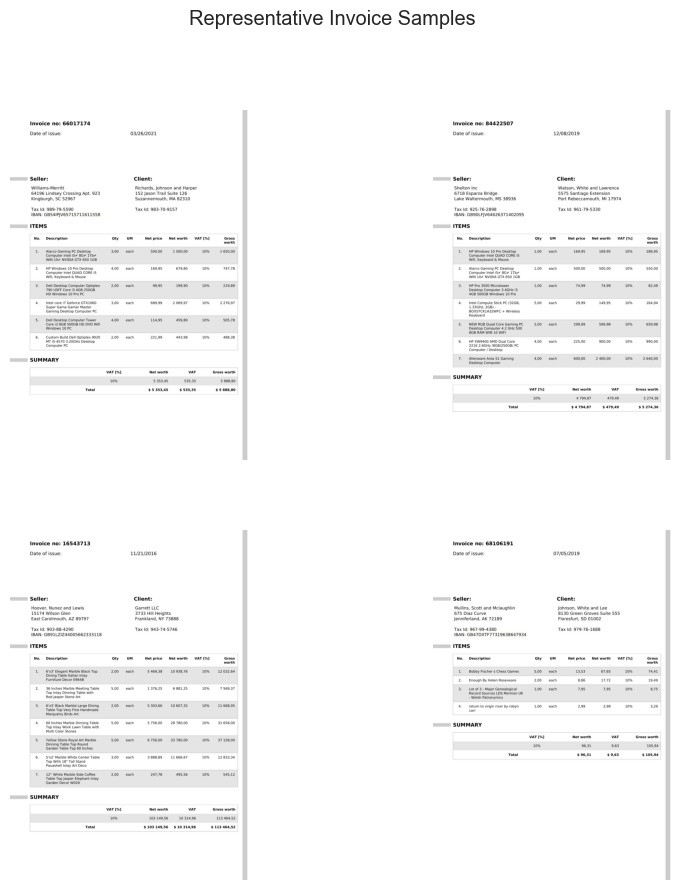

In [198]:
image_sample = df.sample(4)

fig, axes = plt.subplots(2,2, figsize=(10,10))

for ax, (_, row) in zip(axes.flatten(), image_sample.iterrows()):

    folder = row["batch_csv"].replace(".csv","")
    img_path = DATA_DIR / folder / row["File Name"]

    img = Image.open(img_path)

    ax.imshow(img)
    ax.axis("off")

plt.suptitle("Representative Invoice Samples")
plt.show()

# OCR Text Examples

In [199]:
ocr_text_sample = df.sample(10)

for _, row in ocr_text_sample.iterrows():

    print("Invoice number:", row["invoice_number"])
    print("OCR snippet:", row["OCRed Text"][:200])
    print()

Invoice number: 67528272
OCR snippet: Invoice no: 67528272 Date of issue: 01/15/2020 Seller: Client: Reyes Group Adams Inc 68431 Harris Pass 1323 Ford Oval Garciatown, NJ 17040 Port Robert, AR 86160 Tax Id: 999-81-3818 Tax Id: 928-97-3212

Invoice number: 94138597
OCR snippet: Invoice no: 94138597 Date of issue: 02/05/2018 Seller: Client: Ochoa-Scott Green LLC 643 Stream 194 Sara Wells Apt: 125 New Kyleview, ME 77494 Terrellport, OK 77300 Tax Id: 921-82-1053 Tax Id: 965-99-

Invoice number: 27301261
OCR snippet: Invoice no: 27301261 Date of issue: 10/09/2012 Seller: Client: Williams LLC Hernandez-Anderson 72074 Taylor Plains Suite 342 084 Carter Lane Apt 846 West Alexandria, AR 97978 South Ronaldbury, AZ 9103

Invoice number: 21257968
OCR snippet: Invoice no: 21257968 Date of issue: 03/06/2012 Seller: Client: Williams, Barron and Smith Smith Inc 0225 Kathryn Island Suite 828 3493 Graham Mission East Joseshire, KY 09969 Lake Brittanyview, WA 652

Invoice number: 72238973
OCR snippet: In

## Missingness analysis

Explore which of the extracted fields have missing fields and how many.

In [200]:
target_fields = [
    "client_name",
    "seller_name",
    "invoice_number",
    "invoice_date",
    "due_date",
    "tax",
    "total_amount"
]

# Function to enforce data types for target fields
def enforce_invoice_dtypes(df):

    text_cols = [
        "client_name",
        "seller_name",
        "invoice_number"
    ]

    date_cols = [
        "invoice_date",
        "due_date"
    ]

    numeric_cols = [
        "tax",
        "total_amount"
    ]

    df = df.copy()

    # ---------- TEXT FIELDS ----------
    for col in text_cols:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .replace("", np.nan)
        )

    # ---------- DATE FIELDS ----------
    for col in date_cols:

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .replace("", np.nan)
        )

        df[col] = pd.to_datetime(
            df[col],
            errors="coerce"
        )

    # ---------- NUMERIC FIELDS ----------
    for col in numeric_cols:

        df[col] = (
            df[col]
            .astype(str)
            .str.replace(",", "", regex=False)
            .str.replace("$", "", regex=False)
            .str.strip()
            .replace("", np.nan)
        )

        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    return df

df = enforce_invoice_dtypes(df)

missing_table = df[target_fields].isna().sum().sort_values(ascending=False)

print(missing_table)

due_date          1413
total_amount       366
tax                169
client_name          0
seller_name          0
invoice_number       0
invoice_date         0
dtype: int64


Only three fields have missing values: *due_date*, *total_amount*, and *tax*. Since *due_date* does not contain any values across all records, we will drop it.

In [201]:
df.drop(columns=["due_date"], inplace=True)

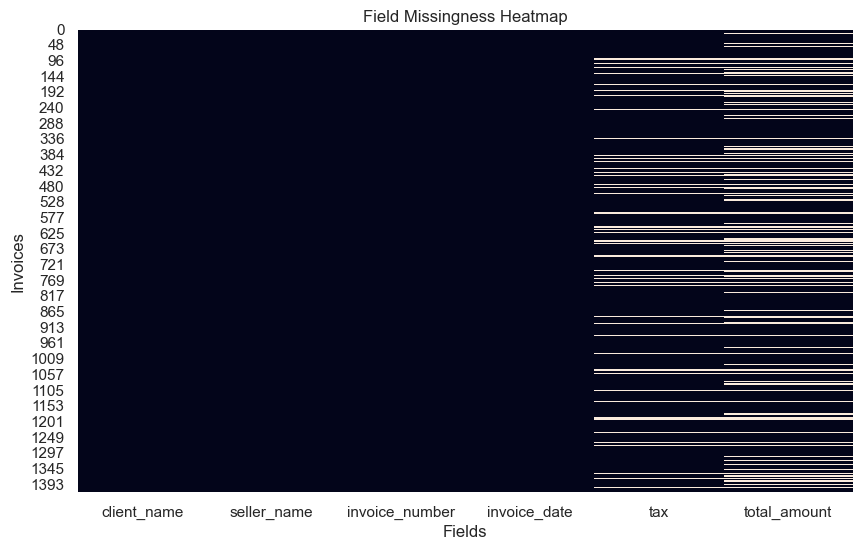

In [204]:
new_target_fields = [
    "client_name",
    "seller_name",
    "invoice_number",
    "invoice_date",
    "tax",
    "total_amount"
]

plt.figure(figsize=(10,6))
sns.heatmap(df[new_target_fields].isna(), cbar=False)
plt.title("Field Missingness Heatmap")
plt.xlabel("Fields")
plt.ylabel("Invoices")
plt.show()

## Vendor distribution
Find how many vendors exist and how many invoices per vendor. 

There are 1361 unique vendors with the top occurring vendors only having 2 or 3 invoices. This may present a large variability in the types of products sold. 

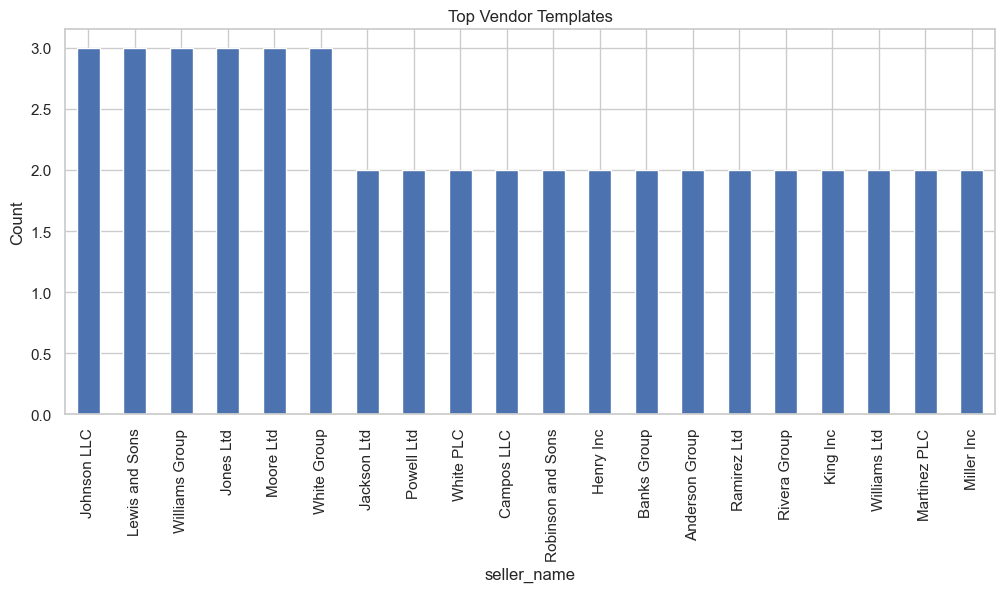

Unique vendors: 1361


In [205]:
vendor_counts = df["seller_name"].value_counts()

plt.figure(figsize=(12,5))
vendor_counts.head(20).plot(kind="bar")
plt.title("Top Vendor Templates")
plt.ylabel("Count")
plt.show()

print("Unique vendors:", df["seller_name"].nunique())

In [206]:
vendor_counts = df["seller_name"].value_counts()
print(vendor_counts)

seller_name
Johnson LLC                     3
Lewis and Sons                  3
Williams Group                  3
Jones Ltd                       3
Moore Ltd                       3
                               ..
Navarro Inc                     1
Mitchell, Acevedo and Wright    1
Thomas, Gonzalez and Bennett    1
Smith, Campbell and Gonzales    1
Burns, Figueroa and Hawkins     1
Name: count, Length: 1361, dtype: int64


## Currency detection
Find the currencies used in the invoices. It turns out they are all in US Dollars.

In [207]:
currency_symbols = ["$", "€", "£", "¥", "₹"]

def detect_currency(text):
    if pd.isna(text):
        return None
    for sym in currency_symbols:
        if sym in text:
            return sym
    return "unknown"

df["currency"] = df["OCRed Text"].apply(detect_currency)

df["currency"].value_counts()

currency
$    1413
Name: count, dtype: int64

## Image resolution & aspect ratio

It seems that the image sizes and aspect ratios are consistent across all image files in the data. 

In [208]:
image_sizes = []
aspect_ratios = []

for i, row in df.iterrows():

    folder = row["batch_csv"].replace(".csv","")
    img_path = DATA_DIR / folder / row["File Name"]

    try:
        img = Image.open(img_path)
        w, h = img.size

        image_sizes.append((w,h))
        aspect_ratios.append(w/h)

    except:
        image_sizes.append((None,None))
        aspect_ratios.append(None)

df["width"] = [x[0] for x in image_sizes]
print(df["width"].value_counts())
df["height"] = [x[1] for x in image_sizes]
print(df["height"].value_counts())

df["aspect_ratio"] = aspect_ratios
print(df["aspect_ratio"].value_counts())

width
1654    1413
Name: count, dtype: int64
height
2339    1413
Name: count, dtype: int64
aspect_ratio
0.70714    1413
Name: count, dtype: int64


## OCR token counts
Measure document complexity. We see that the distribution of token account across all documents is relatively normal. However, there is a large number of invoices with 82-84 tokens per document.

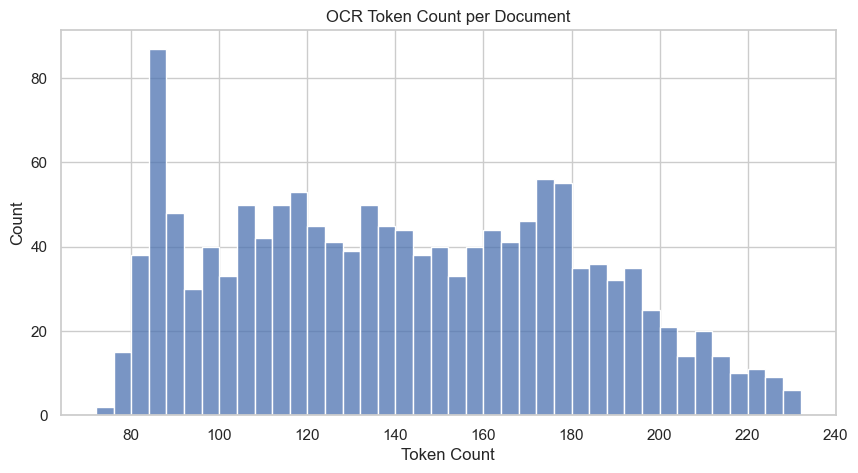

In [229]:
df["ocr_tokens"] = df["OCRed Text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10,5))
sns.histplot(df["ocr_tokens"], bins=40)
plt.title("OCR Token Count per Document")
plt.xlabel("Token Count")
plt.show()

## Word Cloud
Common invoice vocabulary is shown in the word cloud below. The most common words are ones that represent the standard fields like Net worth, Tax, ID, VAT, etc.

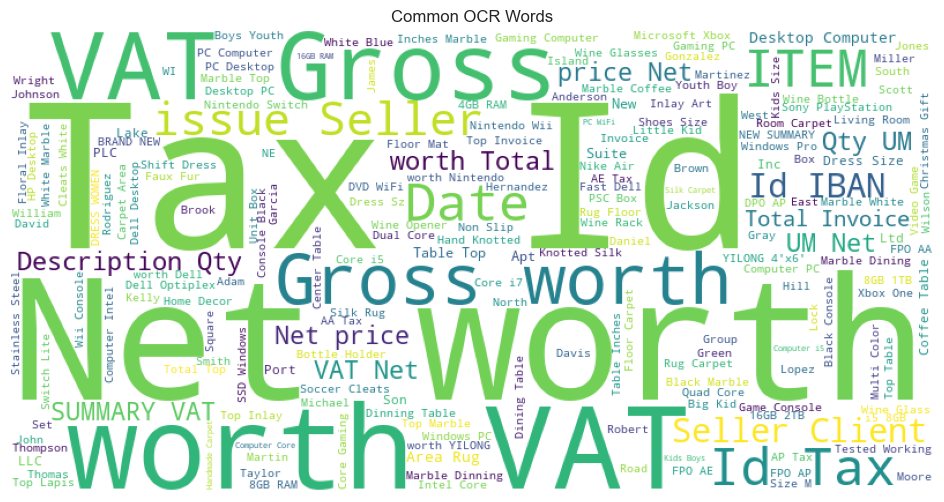

In [210]:
all_text = " ".join(df["OCRed Text"].astype(str))

wc = WordCloud(width=800, height=400, background_color="white").generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.title("Common OCR Words")
plt.show()

## Invoice number statistics

Check to see if the invoice number structure is standardized. We see that all of the invoice numbers are 8 characters long.

In [221]:
df["invoice_number_length"] = df["invoice_number"].astype(str).apply(len)
print(df["invoice_number_length"].value_counts())

invoice_number_length
8    1413
Name: count, dtype: int64


Check for noisy characters in invoice number. There is none.

In [212]:
df["invoice_number"].str.contains("[^0-9A-Za-z]", regex=True).mean()

np.float64(0.0)

## Total amount and tax analysis

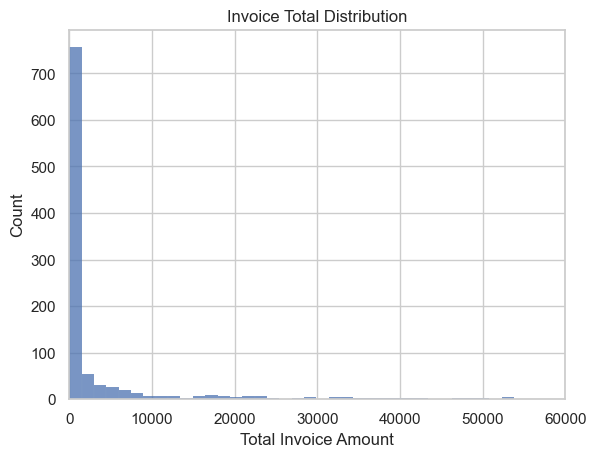

In [224]:
sns.histplot(df["total_amount"].dropna(), bins=2000)
plt.xlim(0, 60000)
plt.title("Invoice Total Distribution")
plt.xlabel("Total Invoice Amount")
plt.show()

Identify the summary statistics for the invoice totals.

In [214]:
print("Summary Statistics of Total Amount:")
df["total_amount"].describe()

Summary Statistics of Total Amount:


count    1.047000e+03
mean     1.466438e+04
std      1.173719e+05
min      1.710000e+00
25%      1.598750e+02
50%      4.289000e+02
75%      2.127700e+03
max      2.989750e+06
Name: total_amount, dtype: float64

In [215]:
print("Number of values:", len(df["total_amount"]))
print("Number of unique values: ", df['total_amount'].nunique())
print("Number of missing values: ", df['total_amount'].isna().sum())

Number of values: 1413
Number of unique values:  1014
Number of missing values:  366


Identify the summary statistics for the invoice tax.

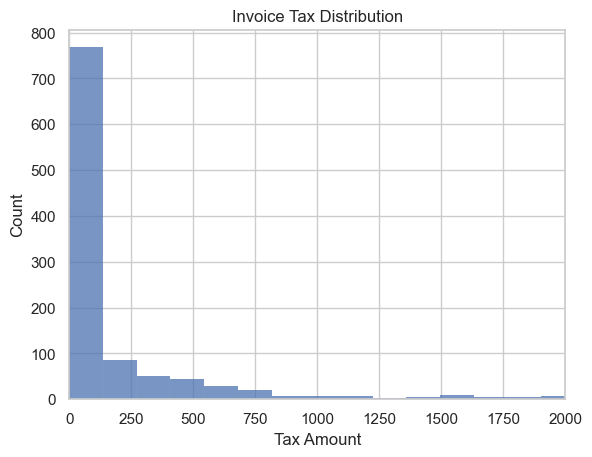

In [225]:
sns.histplot(df["tax"].dropna(), bins=2000)
plt.xlim(0, 2000)
plt.title("Invoice Tax Distribution")
plt.xlabel("Tax Amount")
plt.show()

In [217]:
print("Summary Statistics of Invoice Tax:")
df["tax"].describe()

Summary Statistics of Invoice Tax:


count      1244.000000
mean       4454.880595
std       16153.205612
min           0.160000
25%          17.835000
50%          59.070000
75%         488.397500
max      271795.000000
Name: tax, dtype: float64

In [218]:
print("Number of values:", len(df["tax"]))
print("Number of unique values: ", df['tax'].nunique())
print("Number of missing values: ", df['tax'].isna().sum())

Number of values: 1413
Number of unique values:  1141
Number of missing values:  169
